In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import uproot
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from catboost import CatBoostClassifier, Pool
from catboost.utils import get_roc_curve
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report


Aquí se establecen puntos de corte para eliminar lo que es fondo de lo que es ruido.

In [74]:
# preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
# preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) & (L_END_VZ > 5000) '
preselection_cut = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '
preselection_cut_mc = '(Jpsi_P > 10000) & (mup_PID_MU > 0) & (mum_PID_MU > 0) & (Jpsi_MAXDOCA < 0.15) & (p_PID_P > 0) & ( p_P > 10000)& ( p_PT > 400) & ( pim_P > 2000) & (L_PT > 450) & (Lb_CHI2 < 150) & (L_MASS < 1500) & (L_MASS > 950) & (Jpsi_CHI2 < 4 ) &  (L_CHI2 < 100) '


second_cuts = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'
second_cuts_mc = '(Cos_xi_LP > 0.9999) & (Cos_xi_LbP > 0.99) & (pim_GHOSTPROB < 0.15) & (p_GHOSTPROB < 0.4) & (mum_GHOSTPROB < 0.4) & (mup_GHOSTPROB < 0.4) & (L_END_VZ > 5000) & (Jpsi_BPVDIRA > 0.999)& (Jpsi_MAXDOCA < 0.10)'

In [75]:
total_keys = ['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB']

preslection_keys = ['SUMCHI2','Cos_xi_LbP','Cos_xi_LP','xi_LbP', 'xi_LP' ] # ,'xi_LbP', 'xi_LP' 



training_variables = total_keys+preslection_keys

Se cargan los datos de la simulación de Montecarlo, y se añaden nuevas características.

In [76]:
my_tuple_mc_1 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_2 = uproot.open("/l/izaac/data/24mc/jpsiLambda/mu/00225128_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree;1")
my_tuple_mc_3 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000001_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")
my_tuple_mc_4 = uproot.open("/l/izaac/data/24mc/jpsiLambda/md/00225126_00000002_1.dvtuple.root:Hlt2BandQ_Lb2JpsiLambdaTT/DecayTree")

mc_data1 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ'] + ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data2 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data3 = my_tuple_mc_1.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data4 = my_tuple_mc_2.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_data5 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data6 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'], library="pd", cut="(Lb_BKGCAT==0)&(p_TRUEORIGIN_VZ > 2500)")
mc_data7 = my_tuple_mc_3.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")
mc_data8 = my_tuple_mc_4.arrays(total_keys + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] + ['Jpsi_CHI2'] + ['p_PX'] + ['p_PY'] + ['p_PZ'] + ['L_PX'] + ['L_PY'] + ['L_PZ'] + ['Lb_PX'] + ['Lb_PY'] + ['Lb_PZ']+ ['Lb_MASS']+ ['EVENTNUMBER'] + ['Jpsi_P'] + ['mum_PID_MU'] + ['L_MASS'],library="pd", cut="(Lb_BKGCAT!=0)|(p_TRUEORIGIN_VZ < 2500)")

mc_signal_up = pd.merge(mc_data1, mc_data2, how="outer")
mc_signal_down = pd.merge(mc_data5, mc_data6, how="outer")
mc_signal_merge = pd.merge(mc_signal_up, mc_signal_down, how="outer")

mc_background_up = pd.merge(mc_data3, mc_data4, how="outer")
mc_background_down = pd.merge(mc_data7, mc_data8, how="outer")
mc_background_merge = pd.merge(mc_background_up, mc_background_down, how="outer")

mc_signal_background_merge = pd.merge(mc_signal_merge, mc_background_merge, how="outer")

mc_signal = mc_signal_merge.query(preselection_cut_mc)
mc_bkg= mc_background_merge.query(preselection_cut_mc)

#Creates a new variables like the Cos()...
cos_xi_L = ((mc_signal['p_PX']*mc_signal['L_PX']+mc_signal['p_PY']*mc_signal['L_PY']+mc_signal['p_PZ']*mc_signal['L_PZ'])/(mc_signal['p_P']*mc_signal['L_P']))
cos_xi_Lb = ((mc_signal['p_PX']*mc_signal['Lb_PX']+mc_signal['p_PY']*mc_signal['Lb_PY']+mc_signal['p_PZ']*mc_signal['Lb_PZ'])/(mc_signal['p_P']*mc_signal['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data
mc_signal['Cos_xi_LbP'] = cos_xi_L
mc_signal['Cos_xi_LP'] = cos_xi_Lb
mc_signal['xi_LP'] = xi_L
mc_signal['xi_LbP'] = xi_Lb
mc_signal['SUMCHI2'] = mc_signal['L_CHI2'] + mc_signal['Lb_CHI2'] + mc_signal['Jpsi_CHI2']
mc_signal_selected_chi2  = mc_signal[mc_signal.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_signal['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_signal_selected  = mc_signal_selected_chi2[mc_signal_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_signal_selected_chi2['p_PID_P']].drop_duplicates()

#Creates a new variables like the Cos()...

cos_xi_L = ((mc_bkg['p_PX']*mc_bkg['L_PX']+mc_bkg['p_PY']*mc_bkg['L_PY']+mc_bkg['p_PZ']*mc_bkg['L_PZ'])/(mc_bkg['p_P']*mc_bkg['L_P']))
cos_xi_Lb = ((mc_bkg['p_PX']*mc_bkg['Lb_PX']+mc_bkg['p_PY']*mc_bkg['Lb_PY']+mc_bkg['p_PZ']*mc_bkg['Lb_PZ'])/(mc_bkg['p_P']*mc_bkg['Lb_P']))
xi_L = np.arccos(cos_xi_L)
xi_Lb  = np.arccos(cos_xi_Lb)
#Add the new varaibles to signal_data

mc_bkg['Cos_xi_LP'] = cos_xi_L
mc_bkg['Cos_xi_LbP'] = cos_xi_Lb
mc_bkg['xi_LP'] = xi_L
mc_bkg['xi_LbP'] = xi_Lb
mc_bkg['SUMCHI2'] = mc_bkg['L_CHI2'] + mc_bkg['Lb_CHI2'] + mc_bkg['Jpsi_CHI2']
mc_bkg_selected_chi2  = mc_bkg[mc_bkg.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==mc_bkg['SUMCHI2']].drop_duplicates('EVENTNUMBER')
mc_bkg_selected  = mc_bkg_selected_chi2[mc_bkg_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==mc_bkg_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/javeser/ipykernel_14213/550664457.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LbP'] = cos_xi_L
/tmp/javeser/ipykernel_14213/550664457.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mc_signal['Cos_xi_LP'] = cos_xi_Lb
/tmp/javeser/ipykernel_14213/550664457.py:37: SettingWithCopyWarning: 
A

In [77]:
print(len(mc_data3['Lb_BKGCAT']))
print(len(mc_data3[mc_data3.Lb_BKGCAT == 0]))

44431
3099


Se cargan los datos de los experimentos.

In [78]:
path = "/l/belfern/Datasets/data24_training.pkl"
data24 = pd.read_pickle(path)

#Creates a new variables like the Cos()...

cos_xi_L_data = ((data24['p_PX']*data24['L_PX']+data24['p_PY']*data24['L_PY']+data24['p_PZ']*data24['L_PZ'])/(data24['p_P']*data24['L_P']))
cos_xi_Lb_data = ((data24['p_PX']*data24['Lb_PX']+data24['p_PY']*data24['Lb_PY']+data24['p_PZ']*data24['Lb_PZ'])/(data24['p_P']*data24['Lb_P']))
xi_L_data = np.arccos(cos_xi_L_data)
xi_Lb_data  = np.arccos(cos_xi_Lb_data)

#Add the new varaibles to signal_data
data24['Cos_xi_LP'] = cos_xi_L_data
data24['Cos_xi_LbP'] = cos_xi_Lb_data
data24['xi_LP'] = xi_L_data
data24['xi_LbP'] = xi_Lb_data

data24['SUMCHI2'] = data24['L_CHI2'] + data24['Lb_CHI2'] + data24['Jpsi_CHI2']
data24_selected_chi2  = data24[data24.groupby(['EVENTNUMBER']).transform('min','SUMCHI2')['SUMCHI2']==data24['SUMCHI2']].drop_duplicates('EVENTNUMBER')
data24_selected  = data24_selected_chi2[data24_selected_chi2.groupby(['EVENTNUMBER']).transform('max','p_PID_P')['p_PID_P']==data24_selected_chi2['p_PID_P']].drop_duplicates()

/l/javeser/micromamba/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)


Se seleccionan las variables de entrenamiento.

In [79]:
mc_signal_columns = training_variables + ['Lb_BKGCAT', 'p_TRUEORIGIN_VZ', 'Lb_MASS']
mc_signal_selected = mc_signal_selected[mc_signal_columns]

mc_bkg_columns = training_variables + ['Lb_BKGCAT', 'p_TRUEORIGIN_VZ', 'Lb_MASS']
mc_bkg_selected = mc_bkg_selected[mc_bkg_columns]

data24_selected_columns = training_variables + ['Lb_MASS']
data24_selected = data24_selected[data24_selected_columns]

In [80]:
training_data = mc_signal_selected.merge(mc_bkg_selected.sample(len(mc_bkg_selected)),how='outer')

In [81]:
print(training_data.shape)
print(data24_selected.shape)
print(training_data.columns)
print(data24_selected.columns)

(50357, 42)
(1754865, 40)
Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 'pim_P', 'pim_PT', 'pim_ETA', 'pim_GHOSTPROB', 'SUMCHI2',
       'Cos_xi_LbP', 'Cos_xi_LP', 'xi_LbP', 'xi_LP', 'Lb_BKGCAT',
       'p_TRUEORIGIN_VZ', 'Lb_MASS'],
      dtype='object')
Index(['Jpsi_PT', 'L_END_VRHO', 'L_BPVDIRA', 'L_BPVIP', 'L_BPVIPCHI2',
       'Lb_BPVDIRA', 'Lb_BPVIP', 'Lb_BPVVDRHO', 'Lb_MAXDOCA', 'Lb_P', 'Lb_PT',
       'Lb_CHI2', 'p_PID_P', 'p_MINIP', 'mup_PID_MU', 'L_PT', 'Jpsi_MAXDOCA',
       'Lb_MINIPCHI2', 'L_P', 'Jpsi_BPVDIRA', 'L_CHI2', 'Lb_ETA', 'L_END_VZ',
       'L_END_VX', 'L_END_VY', 'Jpsi_ETA', 'p_P', 'p_PT', 'p_ETA',
       'p_GHOSTPROB', 

In [82]:
training_data

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,pim_ETA,pim_GHOSTPROB,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS
0,19.314734,147.023453,0.999965,39.573761,3.507052,0.999985,0.047439,0.162433,31.689167,195511.375000,...,3.917370,0.133526,7.188199,0.999784,0.999610,0.027938,0.020791,0,3736.9928,5282.650391
1,21.476732,214.000488,0.999994,17.498362,2.426566,0.999020,0.142369,0.082560,8.611194,85697.687500,...,4.073184,0.015913,3.840920,0.999238,0.999909,0.039031,0.013474,110,5116.3571,5012.679688
2,21.476732,217.319351,0.999996,8.972203,1.768888,0.999925,0.039365,0.082516,7.879269,95636.765625,...,2.242929,0.008439,3.564506,0.999758,0.999945,0.010484,0.021981,0,3245.1502,5621.771973
3,34.347198,471.678528,0.999999,9.018121,0.503343,0.999995,0.033852,0.548407,6.100874,55124.441406,...,2.261780,0.006699,2.053615,0.999882,0.999731,0.015356,0.023203,100,4014.3316,5555.461426
4,35.198696,123.505363,0.999990,13.064052,6.157436,0.999869,0.040754,0.034248,12.316824,173047.515625,...,2.014015,0.003790,12.778202,0.999842,0.999338,0.017767,0.036401,100,749.8936,5082.435059
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50352,44845.320312,449.354523,0.999961,33.975163,7.332752,1.000000,0.007062,2.324760,12.161402,532585.312500,...,2.393846,0.006672,7.843421,0.999722,0.999999,0.001505,0.023598,0,2963.6281,5508.531738
50353,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,2.329843,0.019437,1.460683,0.999895,0.999932,0.011673,0.014493,0,5390.6936,5658.234863
50354,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,2.724765,0.021807,10.375792,0.999991,0.999856,0.016989,0.004172,0,5891.9254,5682.604492
50355,59497.332031,219.271698,0.999984,15.984035,3.849400,1.000000,0.011805,8.292579,10.313406,867259.625000,...,2.245543,0.000829,6.704729,0.999491,0.999704,0.031914,0.024349,0,867.2470,5969.040039


In [83]:
# Crea la columna SIGNAL con valor True si el dato es de señal, y False si es de fondo.
# Además, creo una columna CLASS que es 0.0 si el dato es de señal, y NaN si es de fondo.
training_data['SIGNAL'] = False
mask = (training_data['Lb_BKGCAT'] == 0) & (training_data['p_TRUEORIGIN_VZ'] > 2500) & (training_data['p_PID_P'] > 0)
training_data.loc[mask,'CLASS'] = 0 #SIGNAL
training_data.loc[mask,'SIGNAL'] = True

In [84]:
new_training = pd.DataFrame(columns=training_variables + ['Lb_BKGCAT'] + ['p_TRUEORIGIN_VZ'] )
new_training = new_training.merge(training_data.query('(CLASS == 0) '),how='outer')
new_training = new_training.merge(data24_selected.query('(Lb_MASS < 5175) '),how='outer')
new_training = new_training.merge(data24_selected.query('(Lb_MASS > 6100) '),how='outer')
new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)

/tmp/javeser/ipykernel_14213/285418186.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  new_training['SIGNAL'] = new_training['SIGNAL'].fillna(False)


In [85]:
#print(len(new_training[new_training.CLASS == 0]))
print("Número de evento que son señal:  ",len(new_training[new_training.SIGNAL == True]))
print("Número de eventos que son fondo: ",len(new_training[new_training.SIGNAL == False]))

Número de evento que son señal:   28196
Número de eventos que son fondo:  614951


In [86]:
y = new_training.SIGNAL
X_train, X_test, y_train, y_test = train_test_split(new_training, y, random_state=69)
# y_train, y_test = X_train.SIGNAL, X_test.SIGNAL
to_drop = ["SIGNAL", "Lb_BKGCAT", "p_TRUEORIGIN_VZ", 'CLASS','Lb_MASS','Cos_xi_LbP','Cos_xi_LP'] #, ,'xi_L', 'xi_Lb'
X_train.drop(columns=to_drop, inplace=True)
X_test.drop(columns=to_drop, inplace=True)

In [87]:
model_params = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec',
    'auto_class_weights' : 'Balanced'
}

In [88]:
train_dataset = Pool(X_train, y_train, feature_names=list(X_train.columns))
test_dataset = Pool(X_test, y_test, feature_names=list(X_test.columns))

In [89]:
model = CatBoostClassifier(**model_params,custom_metric=['Logloss',
                   'AUC:hints=skip_train~false','Accuracy'])
model.fit(train_dataset, verbose=100, plot=False)

Learning rate set to 0.144123
0:	learn: 0.4638531	total: 48.6ms	remaining: 48.5s
100:	learn: 0.0646406	total: 4.47s	remaining: 39.8s
200:	learn: 0.0497696	total: 8.81s	remaining: 35s
300:	learn: 0.0415846	total: 13.1s	remaining: 30.4s
400:	learn: 0.0353189	total: 17.7s	remaining: 26.4s
500:	learn: 0.0305461	total: 21.9s	remaining: 21.8s
600:	learn: 0.0270128	total: 26.2s	remaining: 17.4s
700:	learn: 0.0240277	total: 30.5s	remaining: 13s
800:	learn: 0.0216787	total: 34.8s	remaining: 8.64s
900:	learn: 0.0197040	total: 39s	remaining: 4.29s
999:	learn: 0.0181600	total: 43.1s	remaining: 0us


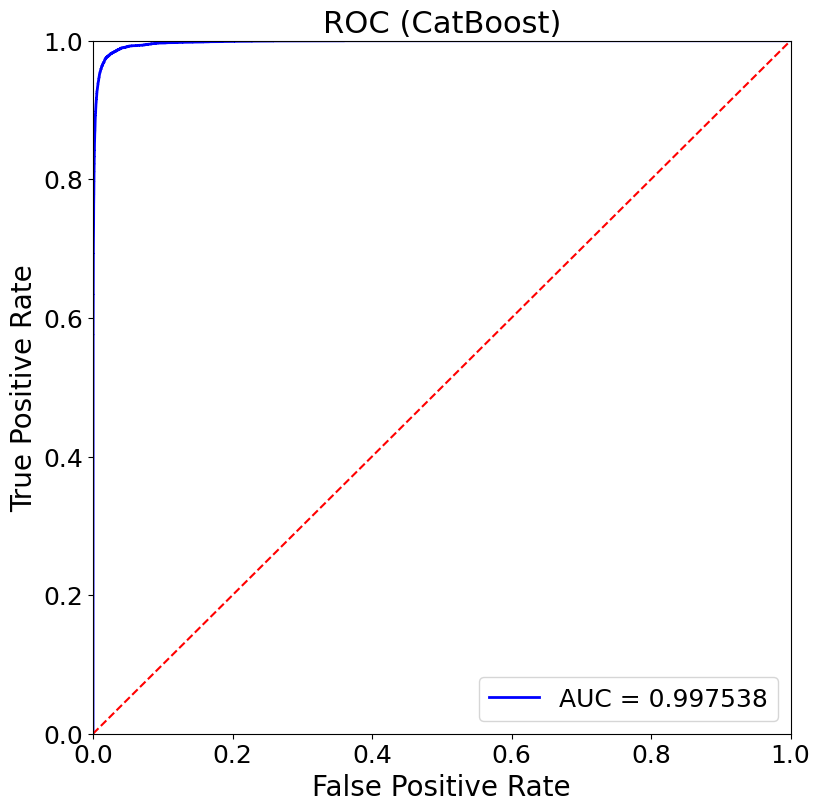

In [90]:
probs = model.predict_proba(X_test)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test, preds)
roc_auc = metrics.auc(fpr, tpr)

plt.title('ROC (CatBoost)', fontsize=22)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=18)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=20)
plt.xlabel('False Positive Rate', fontsize=20)
plt.xticks(fontsize=18) 
plt.yticks(fontsize=18) 
plt.show()

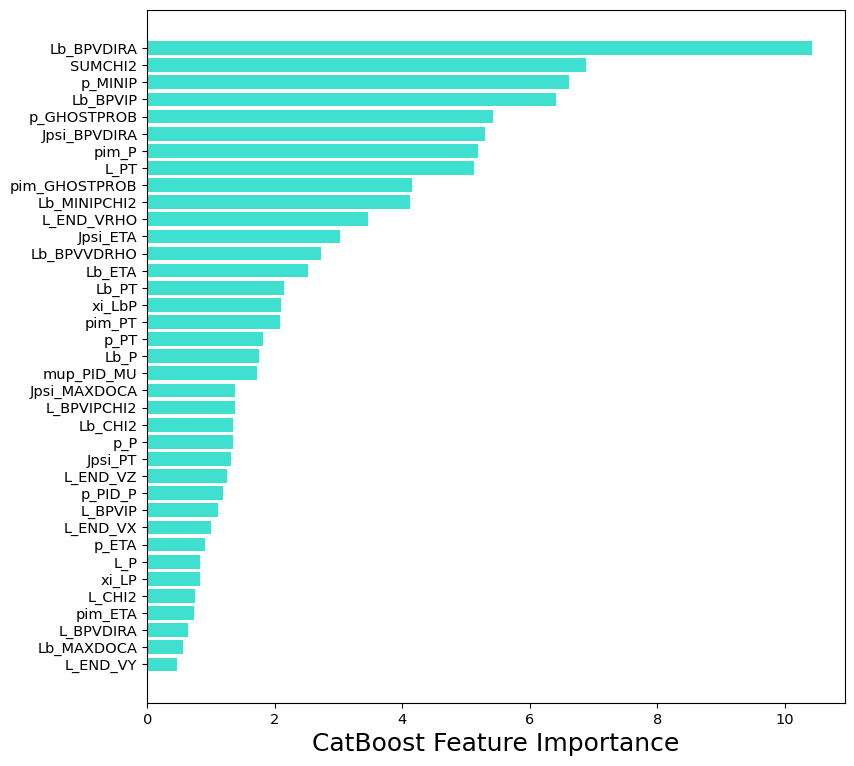

In [91]:
sorted_feature_importance = model.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (9,9)
plt.barh(X_test.columns[sorted_feature_importance], 
        model.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("CatBoost Feature Importance", fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
plt.xticks(fontsize=10.5)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=10.5);  # Ajusta el tamaño de fuente de las etiquetas en el eje y

Hasta aquí he reproducido el trabajo de Javier.

Ahora voy a utilizar un conjunto balancedado.

1. Creo el conjunto con datos de señal y de fondo.
1. Muestreo el conjunto de fondo para reducir el número de muestras al mismo valor que el conjuto de datos de señal.
1. Concateno los dos conjuntos.
1. Barajo el conjunto.

In [92]:
signal = new_training[new_training.SIGNAL]
background = new_training[new_training.SIGNAL == False]
number_signal_samples = len(signal)
background_sampled = background.sample(number_signal_samples, random_state=70)
print("Número de muestras en el conjunto de señal:   ", len(signal))
print("Número de muestras en el cojunto de fondo:    ", len(background_sampled))
signal_and_background = pd.concat([signal, background_sampled])
signal_and_background = signal_and_background.sample(frac=1, random_state=69).reset_index(drop=True)
print("Número de muestras en el conjunto balanceado: ", len(signal_and_background))
# signal_and_background

Número de muestras en el conjunto de señal:    28196
Número de muestras en el cojunto de fondo:     28196
Número de muestras en el conjunto balanceado:  56392


Separo en conjunto de entrenamiento y de prueba.

In [93]:
y = signal_and_background.SIGNAL
X = signal_and_background.drop(columns=to_drop)
X_train_balanced, X_test_balanced, y_train_balanced, y_test_balanced = train_test_split(X, y, random_state=69)

Defino los parámetros para construir el árbol.

In [94]:
model_params_balanced = {
    'iterations': 1000, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'od_type': 'IncToDec'
}

In [95]:
train_dataset_balanced = Pool(X_train_balanced, y_train_balanced, feature_names=list(X_train.columns))
test_dataset_balanced = Pool(X_test_balanced, y_test_balanced, feature_names=list(X_test.columns))

Construyo y entreno el árbol.

In [96]:
model_balanced = CatBoostClassifier(**model_params_balanced, 
                                    custom_metric=['Logloss', 'AUC:hints=skip_train~false',
                                                   'Accuracy'])
model_balanced.fit(train_dataset_balanced, verbose=100, plot=False)

Learning rate set to 0.050975
0:	learn: 0.6019303	total: 6.98ms	remaining: 6.98s
100:	learn: 0.0828697	total: 796ms	remaining: 7.08s
200:	learn: 0.0670244	total: 1.52s	remaining: 6.05s
300:	learn: 0.0573351	total: 2.25s	remaining: 5.21s
400:	learn: 0.0505737	total: 3.02s	remaining: 4.52s
500:	learn: 0.0451431	total: 3.75s	remaining: 3.74s
600:	learn: 0.0407166	total: 4.5s	remaining: 2.99s
700:	learn: 0.0369105	total: 5.25s	remaining: 2.24s
800:	learn: 0.0334619	total: 5.94s	remaining: 1.48s
900:	learn: 0.0305048	total: 6.6s	remaining: 726ms
999:	learn: 0.0279779	total: 7.26s	remaining: 0us


Voy a ver cuál es la matriz de confusión para los datos de prueba.

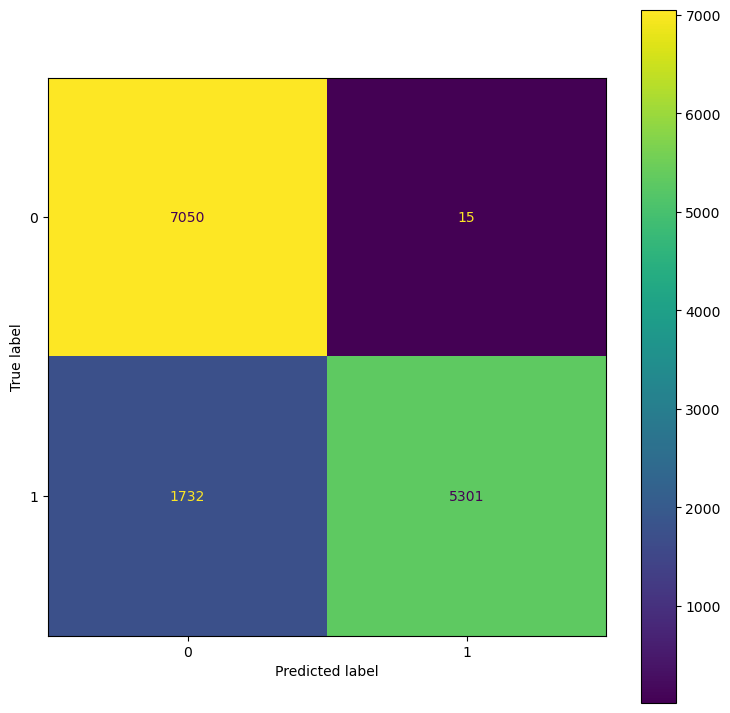

In [97]:
y_pred = [x > 0.99 for x in model_balanced.predict_proba(X_test_balanced)[:,1]]
ConfusionMatrixDisplay(confusion_matrix(y_test_balanced, y_pred)).plot()

Una vez que tengo creado el árbol, a partir de los datos de Montecarlo, lo utilizo para clasificar los eventos de los experimentos como pertenecientes a señal o a fondo.

In [98]:
maxima_probabilidad = 0.99
filtro = model.predict_proba(data24_selected)[:,1] >= maxima_probabilidad
data24_signal = data24_selected[filtro]
data24_background = data24_selected[filtro]
print(data24_signal.shape)

(2503, 40)


Muestros el histograma de los datos parala masa de Lb: todos los datos del experimento, aquellos que Catboost ha calificado como señal, y lo que ha clasificado como fondo.

Candidatos totales:  1754865
Candidatos positivos (clasificados con Catboost):  2503
Masa de Lb con todos los datos:                         5661.081585081587
Masa de Lb sólo con los datos clasificados como señal:  5522.449511757776
Desviación estandar:  259.0536879698096
La masa que aparece en la wikipedia es:                 5619.6


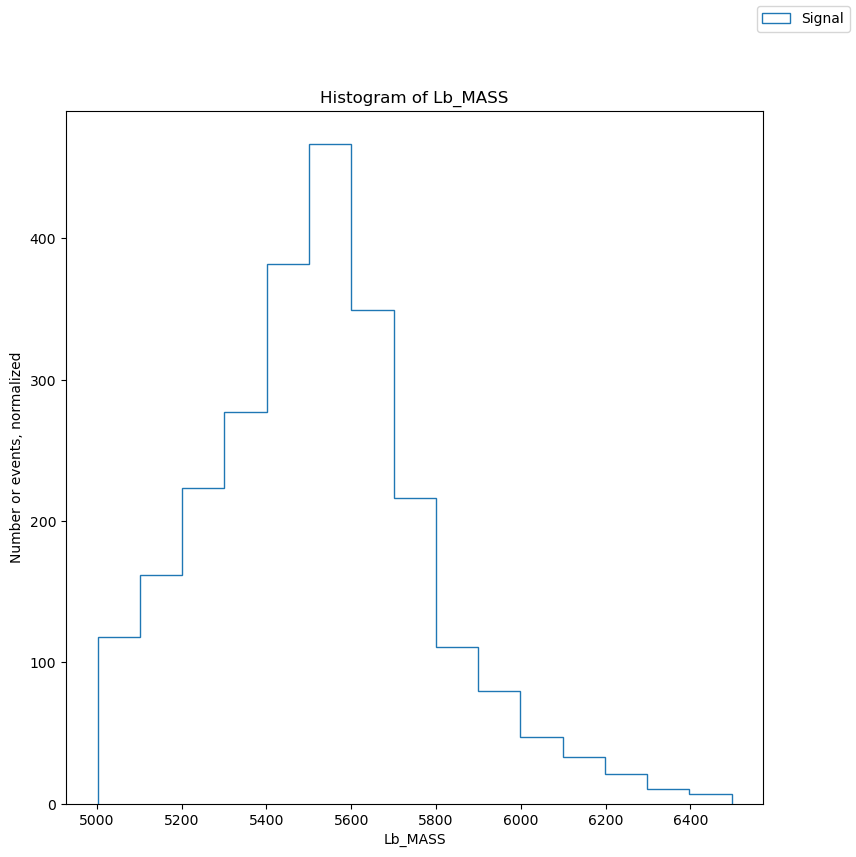

In [99]:
bins = 15
caracteristica = 'Lb_MASS'
density = False
# plt.hist(data24_selected[caracteristica], bins=bins, density=True, histtype='step', label='All data');
plt.hist(data24_signal[caracteristica], bins=bins, density=density, histtype='step', label='Signal');
# plt.hist(data24_background[caracteristica], bins=bins, density=True, histtype='step', label='Background')
# plt.hist(data24_selected[caracteristica], bins=bins, histtype='step', label='All data');
# plt.hist(data24_signal[caracteristica], bins=bins, histtype='step', label='Signal');
# plt.hist(data24_background[caracteristica], bins=bins, histtype='step', label='Background')
plt.xlabel(caracteristica)
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ caracteristica)
plt.figlegend()
print("Candidatos totales: ", data24_selected.shape[0])
print("Candidatos positivos (clasificados con Catboost): ", data24_signal.shape[0])
print('Masa de Lb con todos los datos:                        ', np.mean(data24_selected.Lb_MASS))
print('Masa de Lb sólo con los datos clasificados como señal: ', np.mean(data24_signal.Lb_MASS))
print('Desviación estandar: ', np.std(data24_signal.Lb_MASS))
print('La masa que aparece en la wikipedia es:                ', 5619.60)

# plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='All data');

Muestro la gráfica ROC.

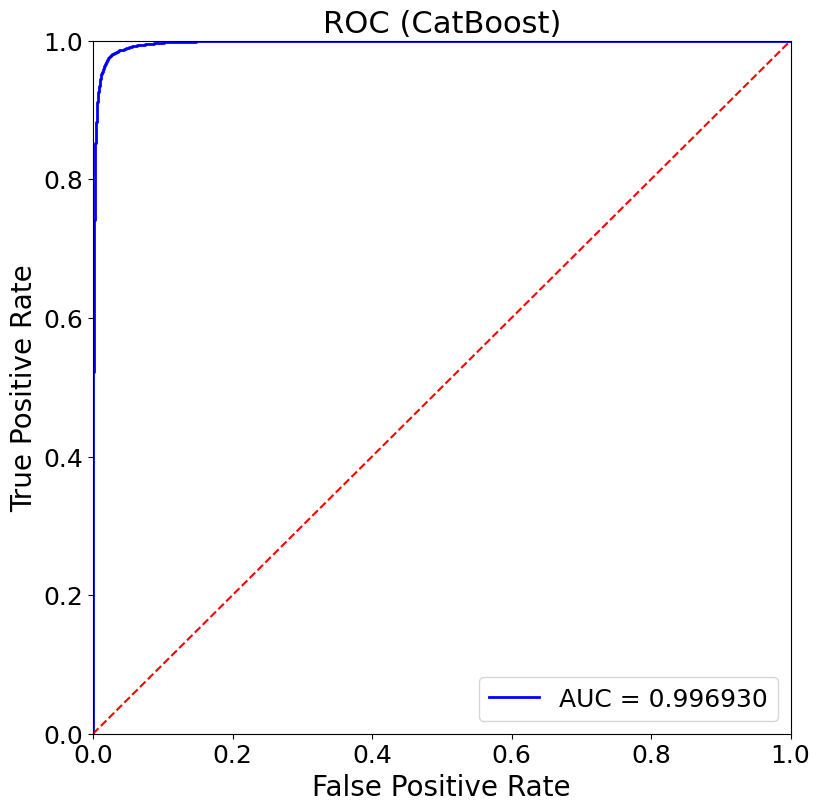

In [100]:
probs = model_balanced.predict_proba(X_test_balanced)
preds = probs[:,1]
fpr, tpr, threshold = metrics.roc_curve(y_test_balanced, preds)
roc_auc = metrics.auc(fpr, tpr)

plt.title('ROC (CatBoost)', fontsize=22)
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.6f' % roc_auc, linewidth=2)
plt.legend(loc = 'lower right', fontsize=18)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate', fontsize=20)
plt.xlabel('False Positive Rate', fontsize=20)
plt.xticks(fontsize=18) 
plt.yticks(fontsize=18) 
plt.show()

Muestro la característicsa que más influyen en la clasificación de una muestra.

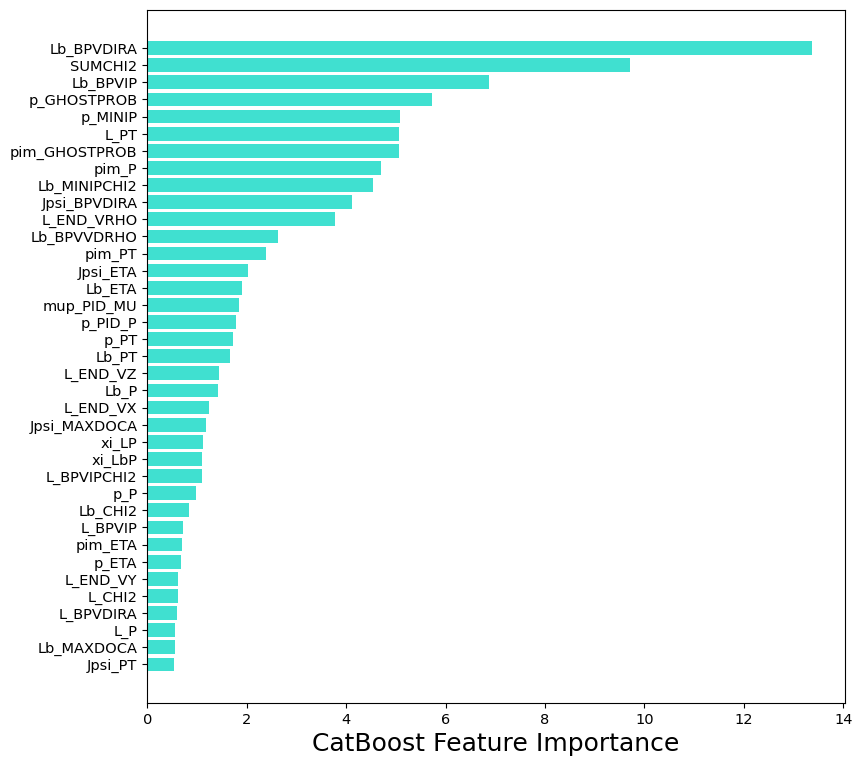

In [101]:
sorted_feature_importance = model_balanced.feature_importances_.argsort()
plt.rcParams["figure.figsize"] = (9,9)
plt.barh(X_test.columns[sorted_feature_importance], 
        model_balanced.feature_importances_[sorted_feature_importance], 
        color='turquoise')
plt.xlabel("CatBoost Feature Importance", fontsize=18)  # Ajusta el tamaño de fuente de las etiquetas en el eje y
plt.xticks(fontsize=10.5)  # Ajusta el tamaño de fuente de las marcas en el eje x
plt.yticks(fontsize=10.5);  # Ajusta el tamaño de fuente de las etiquetas en el eje y

A partir de aquí un poco de juego.

In [102]:
# # plt.hist(background_sampled.Lb_BPVDIRA, bins=1000, label="Background")
# plt.hist(signal.Lb_BPVDIRA, bins=100, label="Signal")
# # plt.xlim(0.8,1)
# plt.figlegend();

In [103]:
# plt.scatter(np.sort(signal.Lb_BPVDIRA), np.sort(background_sampled.Lb_BPVDIRA));

In [104]:
print(np.min(signal.Lb_BPVDIRA))
print(np.min(background_sampled.Lb_BPVDIRA))

0.98526096
0.98500335


In [105]:
# plt.plot(np.sort(signal.Lb_BPVDIRA))
# plt.plot(np.sort(background_sampled.Lb_BPVDIRA));

In [106]:
# plt.hist(signal.SUMCHI2, bins=100)
# plt.hist(background_sampled.SUMCHI2, bins=100)
# ;

In [107]:
# # plt.scatter(signal.Lb_BPVDIRA, signal.SUMCHI2)
# # plt.scatter(background_sampled.Lb_BPVDIRA, background_sampled.SUMCHI2)
# plt.scatter(signal.Lb_BPVDIRA, signal.Lb_BPVIP)
# # plt.scatter(background_sampled.Lb_BPVDIRA, background_sampled.Lb_BPVIP);


In [108]:
signal_and_background

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SIGNAL,CLASS
0,3530.641113,406.650543,0.999981,36.822308,35.024426,0.992716,0.049033,0.075570,28.943932,44935.753906,...,38.294314,0.994746,0.999878,0.102553,0.015644,NaN,NaN,6207.530762,False,NaN
1,3880.825439,268.014343,1.000000,1.061152,0.016864,0.999990,0.032766,0.445736,2.380782,114338.859375,...,1.333839,0.999984,0.999854,0.017087,0.005642,0.0,6187.6492,5539.912109,True,0.0
2,2941.197266,83.056938,0.999881,57.383205,32.542915,0.999790,0.024555,0.013682,20.408594,83620.742188,...,46.027369,0.996214,0.999699,0.087044,0.024553,NaN,NaN,5007.736328,False,NaN
3,1726.835938,295.176086,1.000000,7.389431,3.175926,0.999968,0.073595,0.175879,7.801791,184089.265625,...,4.732499,0.999631,0.999996,0.027181,0.002719,NaN,NaN,6165.490234,False,NaN
4,1673.955811,600.278931,0.999999,10.387090,2.183446,0.999939,0.035447,0.240470,8.627779,61592.769531,...,5.561988,0.999993,0.999750,0.022358,0.003845,0.0,6656.2319,5065.281250,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56387,3269.813232,299.198975,0.999999,6.902085,1.926531,0.999999,0.008440,0.291472,6.537942,109390.695312,...,2.328246,0.999973,0.999547,0.030111,0.007373,0.0,6291.5646,5573.644043,True,0.0
56388,3219.792725,132.073364,0.999991,13.507992,3.772722,0.998298,0.052025,0.041257,2.270328,103898.218750,...,7.071041,0.999123,0.999896,0.041890,0.014444,NaN,NaN,6365.740723,False,NaN
56389,8753.200195,1037.836426,1.000000,4.818660,0.920030,0.999997,0.048044,3.479021,4.805304,87649.101562,...,3.393697,0.999994,0.999642,0.026741,0.003383,0.0,6647.5248,5419.000977,True,0.0
56390,2813.272949,160.401138,1.000000,1.149706,0.026806,0.999998,0.039909,0.986630,4.383309,133644.906250,...,0.684340,0.999933,0.999666,0.025857,0.011534,0.0,4541.5834,5722.637695,True,0.0


Se acabó el juego anterior.

Para no tener que copiar mucho código, sigo aquí viendo qué pasa con PCA.

In [109]:
def set_clazz(x):
    if x:
        return "GREEN"
    else:
        return "RED"

Creo y entreno el PCA. Hay que escalar los datos para que los más **dispersos** no tengan más pesos en el análisis.

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

data_without_nan = signal_and_background.drop(columns=['Lb_BKGCAT', 'p_TRUEORIGIN_VZ', 'CLASS'])
data_without_nan = data_without_nan.dropna()
clazz = [set_clazz(x) for x in data_without_nan.SIGNAL] 
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_without_nan)
pca = PCA(n_components=0.9)
data_pca = pca.fit_transform(data_scaled)
print(data_pca.shape)
print(signal_and_background.shape)
# signal_and_background.CLASS = clazz
# signal_and_background
# data_without_nan
print(data_without_nan[data_without_nan.SIGNAL].shape)
print(data_without_nan[data_without_nan.SIGNAL == False].shape)

(56274, 22)
(56392, 44)
(28080, 41)
(28194, 41)


In [111]:
explained_variance = pca.explained_variance_ratio_
cum_explained_variance = [sum(explained_variance[0:i+1]) for i in range(len(explained_variance))]
x_range = range(1,len(explained_variance)+1)

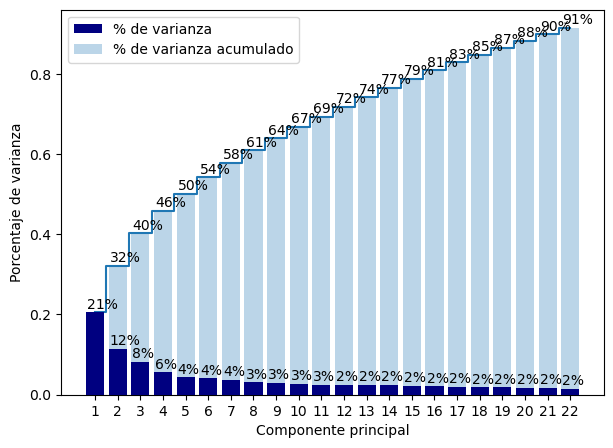

In [112]:
fig, ax = plt.subplots(figsize = (7, 5))
ax.bar(x = x_range, height = explained_variance, zorder = 20,
       color = "navy", label = "% de varianza")
ax.bar(x = x_range, height = cum_explained_variance, alpha = 0.3,
       label = "% de varianza acumulado")
ax.step(x = x_range, y = cum_explained_variance, where = "mid")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Porcentaje de varianza")
for i, v in enumerate(explained_variance):
    ax.text(x = i + 0.65, y = v + 0.01, s = str(round(v * 100)) + "%")
for i, v in enumerate(cum_explained_variance[1:], start = 1):
    ax.text(x = i + 0.65, y = v + 0.01, s = str(round(v * 100)) + "%")
ax.set_xticks(x_range, labels = x_range)
ax.legend()
plt.show()

Ahora voy a ver cómo de bien se separan los datos si sólo tomo las dos primeras variables después de PCA.

Voy a ver si con las dos primeras variables que encuentra PCA es posible separar los datos de señal y de fondo, utiliznado una regresión logística.

In [113]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.inspection import DecisionBoundaryDisplay

# pca = PCA(n_components=2)
# X_pca = pca.fit_transform(data_without_nan)
# X_train, X_test, y_train, y_test = train_test_split(X_pca, clazz)

# logistic = LogisticRegression()
# logistic.fit(X_train, y_train)

# class_names = ["Class " + str(n) for n in y.unique()]

# DecisionBoundaryDisplay.from_estimator(
#     logistic,
#     X_pca,
#     cmap=plt.cm.Paired,
#     ax=ax,
#     response_method="predict",
#     plot_method="pcolormesh",
#     shading="auto",
#     xlabel="Uno",
#     ylabel="Dos",
#     eps=0.5,
# ).plot()

# plt.scatter(X_train[:,0], X_train[:,1], c = y_train);

No parece que sea posible la separación utilizando tan sólo las dos primeras variables que ha encontrado PCA.

Voy a probara clasificar con un MLP.

In [114]:
new_training

,Jpsi_PT,L_END_VRHO,L_BPVDIRA,L_BPVIP,L_BPVIPCHI2,Lb_BPVDIRA,Lb_BPVIP,Lb_BPVVDRHO,Lb_MAXDOCA,Lb_P,...,SUMCHI2,Cos_xi_LbP,Cos_xi_LP,xi_LbP,xi_LP,Lb_BKGCAT,p_TRUEORIGIN_VZ,Lb_MASS,SIGNAL,CLASS
0,3.849078,410.608185,0.999996,19.165550,13.589819,0.999425,0.059135,0.073100,17.049515,56427.265625,...,48.184564,0.997900,0.999382,0.064826,0.035155,NaN,NaN,5031.431641,False,NaN
1,4.422329,135.734070,0.999994,23.802071,13.575705,0.995400,0.022364,0.019789,14.871126,102998.156250,...,15.007227,0.999997,0.999999,0.002441,0.001337,NaN,NaN,6367.910156,False,NaN
2,6.669048,246.652206,0.999951,59.099663,23.576298,0.993098,0.119942,0.142081,44.417614,57631.667969,...,55.043813,0.999084,0.998763,0.042814,0.049754,NaN,NaN,5032.116699,False,NaN
3,7.510327,474.330933,0.999944,45.999870,13.434136,0.999938,0.034355,0.092999,40.610912,90956.242188,...,41.574463,0.995920,0.998312,0.090358,0.058103,NaN,NaN,6454.255859,False,NaN
4,7.852063,87.560501,0.999949,28.015650,1.105828,0.987323,0.052615,0.045138,20.732306,73919.953125,...,1.440960,0.999696,0.999944,0.024643,0.010603,NaN,NaN,6308.567871,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643142,45208.921875,276.850189,0.999990,15.352786,9.211822,1.000000,0.010112,4.010145,13.048256,624606.312500,...,19.583451,0.998986,0.999139,0.045028,0.041510,NaN,NaN,6439.879395,False,NaN
643143,45588.246094,221.630081,0.999981,22.697388,8.513816,1.000000,0.067056,4.170573,19.741793,843784.625000,...,11.577746,0.999877,0.999849,0.015675,0.017387,NaN,NaN,5109.050781,False,NaN
643144,45604.070312,850.732910,0.999999,8.286180,0.661572,0.999995,0.009449,0.413043,6.827459,400083.156250,...,1.460683,0.999895,0.999932,0.011673,0.014493,0.0,5390.6936,5658.234863,True,0.0
643145,46152.855469,1005.125000,0.999998,14.163650,6.015148,0.999995,0.023944,1.014155,11.011504,419546.875000,...,10.375792,0.999991,0.999856,0.016989,0.004172,0.0,5891.9254,5682.604492,True,0.0


In [115]:
27//2

13

In [124]:
import joblib
def cambiatruefalse(x):
    if x:
        return 1
    else:
        return 0

mlp_data = data_without_nan.copy()

X = mlp_data.drop(columns=['SIGNAL'])
scaler = StandardScaler()
X = scaler.fit_transform(X)


y = [cambiatruefalse(x) for x in mlp_data.SIGNAL]
# y = mlp_data.SIGNAL

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=69)

neuronas = X_train.shape[1]


mlp = MLPClassifier(
    hidden_layer_sizes=(neuronas, neuronas//2, neuronas//4),
    learning_rate_init=0.001,
    solver = 'lbfgs',
    max_iter = 1000,
    random_state = 69
)

mlp.fit(X_train, y_train);

# Guardar el modelo entrenado
joblib.dump(mlp, 'neural_network.pkl')

['neural_network.pkl']

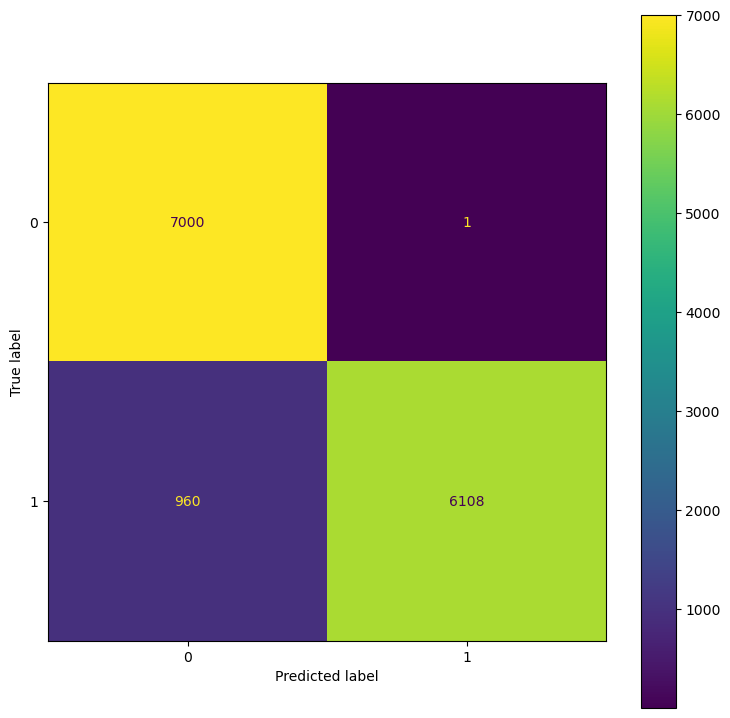

In [117]:
y_pred = mlp.predict_proba(X_test)[:,1] >= 0.99999999999999999

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot()

Candidatos totales:  1754575
Candidatos positivos (clasificados con MLP):  186803
Masa de Lb con todos los datos:                         5661.080012876493
Masa de Lb sólo con los datos clasificados como señal:  5573.592078416372
Desviación estandar de la media de la masa de Lb     : 220.8847486194917
La masa que aparece en la wikipedia es:                 5619.6


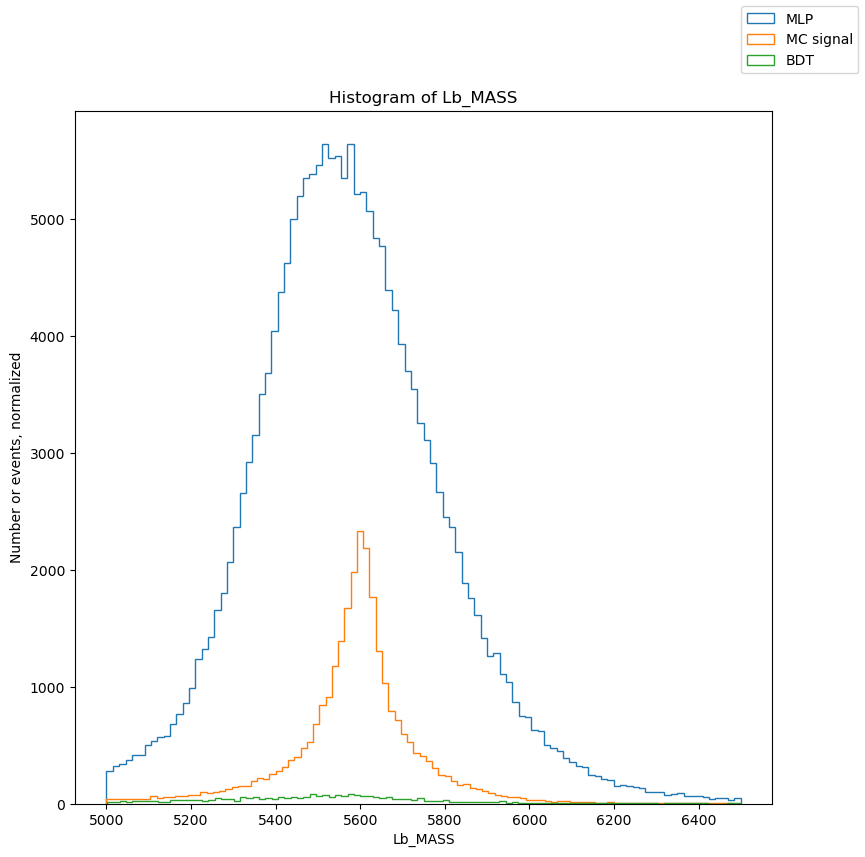

In [118]:
# 
data24_selected_nan = data24_selected.dropna()

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.9999999999999999
# y_pred = mlp.predict(data24_selected_nan_scaled)
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:,1] > maxima_probabilidad


data24_signal_nan = data24_selected_nan[y_pred]
data24_background_nan = data24_selected_nan[y_pred == False]

bins =100
caracteristica = 'Lb_MASS'
# plt.hist(data24_selected_nan[caracteristica], bins=bins, density=True, histtype='step', label='All data');
# plt.hist(data24_signal_nan[caracteristica], bins=bins, density=True, histtype='step', label='MLP');
# plt.hist(data24_background_nan[caracteristica], bins=bins, density=True, histtype='step', label='Background')
# plt.hist(data24_selected_nan[caracteristica], bins=bins, histtype='step', label='All data');
plt.hist(data24_signal_nan[caracteristica], bins=bins, histtype='step', label='MLP');
# plt.hist(data24_background_nan[caracteristica], bins=bins, histtype='step', label='Background')
plt.xlabel(caracteristica)
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ caracteristica)
print("Candidatos totales: ", data24_selected_nan.shape[0])
print("Candidatos positivos (clasificados con MLP): ", data24_signal_nan.shape[0])
print('Masa de Lb con todos los datos:                        ', np.mean(data24_selected_nan.Lb_MASS))
print('Masa de Lb sólo con los datos clasificados como señal: ', np.mean(data24_signal_nan.Lb_MASS))
print('Desviación estandar de la media de la masa de Lb     :', np.std(data24_signal_nan.Lb_MASS))
print('La masa que aparece en la wikipedia es:                ', 5619.60)

plt.hist(mc_signal['Lb_MASS'], bins=bins, density=False, histtype='step', label='MC signal');
plt.hist(data24_signal[caracteristica], bins=bins, density=False, histtype='step', label='BDT');
plt.figlegend()

A partir de aqui codigo nuevo y modificado 

In [119]:

from sklearn.preprocessing import StandardScaler

# Suponiendo que data24_selected ya está definido
data24_selected_nan = data24_selected.dropna()

scaler = StandardScaler()
data24_selected_nan_scaled = scaler.fit_transform(data24_selected_nan)

maxima_probabilidad = 0.9999999999999999

# Predecir probabilidades en el nuevo conjunto de datos
y_pred = mlp.predict_proba(data24_selected_nan_scaled)[:, 1]

# Filtrar los datos que cumplan con la condición
high_confidence_indices = y_pred > maxima_probabilidad
high_confidence_data = data24_selected_nan[high_confidence_indices]

# Guardar los datos en un archivo CSV
high_confidence_data.to_csv('Neural_network_data.csv', index=False)


In [120]:

# Cargar los datos desde el archivo CSV
neural_data = pd.read_csv('Neural_network_data.csv')

# Ahora puedes trabajar con high_confidence_data
maxima_probabilidad = 0.95
filtro = model.predict_proba(neural_data)[:,1] >= maxima_probabilidad
neural_data_signal = neural_data[filtro]
neural_data_bkg = neural_data[filtro]
print(neural_data.shape)

(186803, 40)


Esto es el resultado de aplicar la BDT después de la neural network 

Candidatos totales:  1754865
Candidatos positivos (clasificados con Catboost):  2503
Masa de Lb con todos los datos:                         5661.081585081587
Masa de Lb sólo con los datos clasificados como señal:  5522.449511757776
Desviación estandar:  259.0536879698096
La masa que aparece en la wikipedia es:                 5619.6


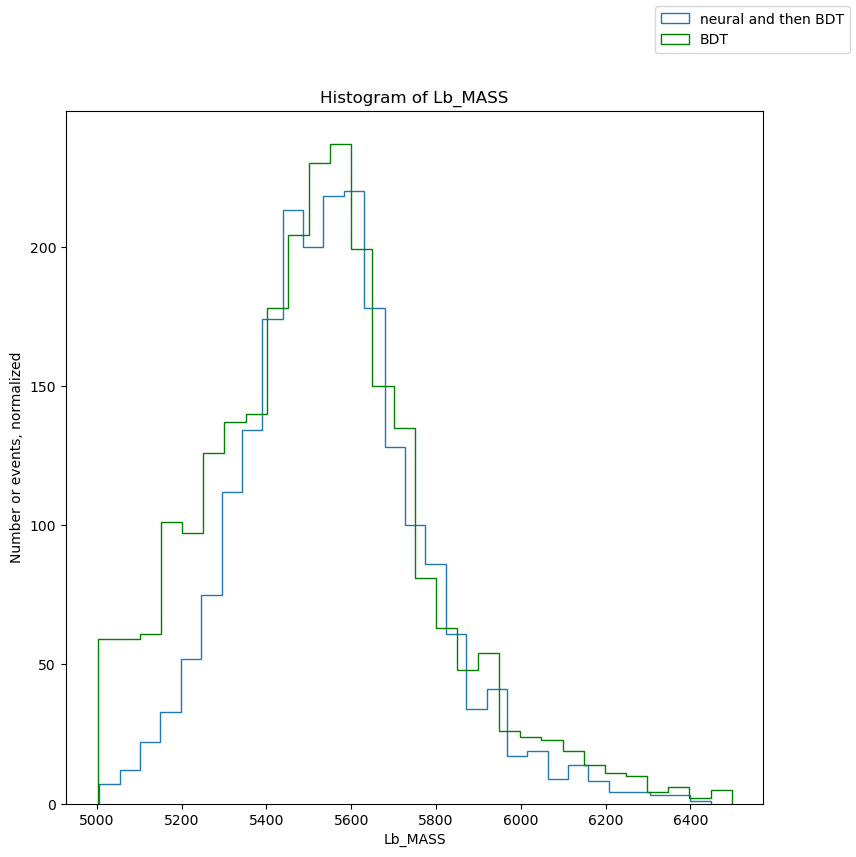

In [121]:
bins = 30
caracteristica = 'Lb_MASS'
density = False
# plt.hist(data24_selected[caracteristica], bins=bins, density=True, histtype='step', label='All data');
plt.hist(neural_data_signal[caracteristica], bins=bins, density=density, histtype='step', label='neural and then BDT');
plt.hist(data24_signal[caracteristica], bins=bins, density=density, histtype='step', label='BDT', color='green');
# plt.hist(data24_background[caracteristica], bins=bins, density=True, histtype='step', label='Background')
# plt.hist(data24_selected[caracteristica], bins=bins, histtype='step', label='All data');
# plt.hist(data24_signal[caracteristica], bins=bins, histtype='step', label='Signal');
# plt.hist(data24_background[caracteristica], bins=bins, histtype='step', label='Background')
plt.xlabel(caracteristica)
plt.ylabel('Number or events, normalized')
plt.title('Histogram of '+ caracteristica)
plt.figlegend()
print("Candidatos totales: ", data24_selected.shape[0])
print("Candidatos positivos (clasificados con Catboost): ", data24_signal.shape[0])
print('Masa de Lb con todos los datos:                        ', np.mean(data24_selected.Lb_MASS))
print('Masa de Lb sólo con los datos clasificados como señal: ', np.mean(data24_signal.Lb_MASS))
print('Desviación estandar: ', np.std(data24_signal.Lb_MASS))
print('La masa que aparece en la wikipedia es:                ', 5619.60)


# plt.hist(mc_signal['Lb_MASS'], bins=bins, density=density, histtype='step', label='All data');